# Intro & 문제 정의

## 데이터셋 정보

- 2013년 9월 유럽 신용카드 사용자들의 거래 내역을 포함하고 있습니다.
- 이 데이터셋은 이틀 간의 거래 내역으로 데이터셋은 크게 불균형하며, 사기 거래(양성 클래스)는 전체 거래의 약 0.17%에 불과합니다.

- 이 데이터셋은 PCA 변환을 거친 수치형 변수들만 포함하고 있습니다. 
- 원본 특징과 데이터에 대한 자세한 배경 정보는 제공할 수 없습니다
- V1, V2, …, V28은 PCA로 얻은 주성분이며
- **PCA 변환을 거치지 않은 유일한 특징은 'Time'과 'Amount'** 입니다. 
    - 'Time'은 각 거래와 데이터셋의 첫 거래 사이의 경과 시간(초)을 나타내며, 
    - 'Amount'는 거래 금액입니다. 'Amount' 특징은 예시 의존적 비용 민감 학습 등에 사용될 수 있습니다. 
- 'Class'는 응답 변수로, 사기 거래인 경우 1, 그렇지 않은 경우 0의 값을 가집니다.

- 클래스 불균형 비율을 고려하여, **정밀도-재현율 곡선 아래 영역(AUPRC)을 사용하여 정확도를 측정**할 것을 권장합니다. 
- 불균형 분류에서는 혼동 행렬 정확도가 큰 의미가 없습니다.
---
이 데이터셋은 Worldline과 ULB(브뤼셀 자유 대학교) 머신러닝 그룹(http://mlg.ulb.ac.be) 간의 빅데이터 마이닝 및 사기 탐지 관련 연구 협력을 통해 수집 및 분석되었습니다.
관련 주제에 대한 현재 및 과거 프로젝트에 대한 자세한 내용은 https://www.researchgate.net/project/Fraud-detection-5 및 DefeatFraud 프로젝트 페이지에서 확인할 수 있습니다.

## 목표 및 루브릭 
- 목표 : 신용카드 사기 검출을 분류
    - 예측할 값(y): Class (0:Not fraud, 1:fraud)
    - 모델 평가 지표 : f1-score 
- 루브릭
    - 데이터 이해 및 탐색: Class의 균형과 데이터의 분포와 특성을 시각화를 통해서 파악했는가?
    - 모델 선택 및 비교: 3개 이상의 모델을 학습시키고 성능을 비교했는가?
    - 레이블 불균형을 처리하기 위한 기법을 시도했는가?
    - 여러 모델을 앙상블을 통해 결합하여 성능을 비교했는가?
    - Ridge/Lasso 등의 규제 추가, 트리 기반 모델의 깊이/학습률 등 하이퍼파라미터를 조정하여 성능 향상을 시도했는가?
- 유의사항 : 클래스 불균형, 원본데이터 특징 없음

# DEA, 데이터 확인 

In [1]:
# 로컬 가상환경 확인용 
import sys
print(sys.executable)

d:\pytest\mdls_mq\.venv\Scripts\python.exe


In [2]:
# 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# 경고 메시지 숨기기
import warnings
warnings.filterwarnings('ignore')

In [3]:
# 데이터 파일 불러오기 
train_df = pd.read_csv('./train.csv')
test_df = pd.read_csv('./test.csv')
print("train_df:", train_df.shape)
print("test_df:", test_df.shape)

train_df: (170883, 32)
test_df: (113923, 31)


In [4]:
train_df.head()

,id,Time,V1,V2,V3,V4,V5,V6,V7,V8,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
# class 컬럼 분포 확인 
train_df['Class'].value_counts(normalize=True)

Class
0    0.997893
1    0.002107
Name: proportion, dtype: float64

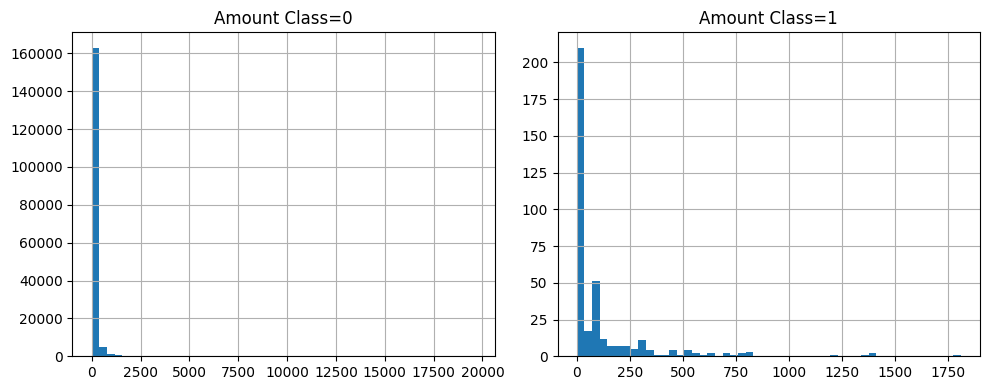

In [6]:
#  Class - Amount 분포 시각화 사기-정상 금액 패턴 확인

# 정상 Class=0
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
train_df[train_df['Class'] == 0]['Amount'].hist(bins=50)
plt.title('Amount Class=0')

# 사기 Class=1
plt.subplot(1, 2, 2)
train_df[train_df['Class'] == 1]['Amount'].hist(bins=50)
plt.title('Amount Class=1')
plt.tight_layout()
plt.show()

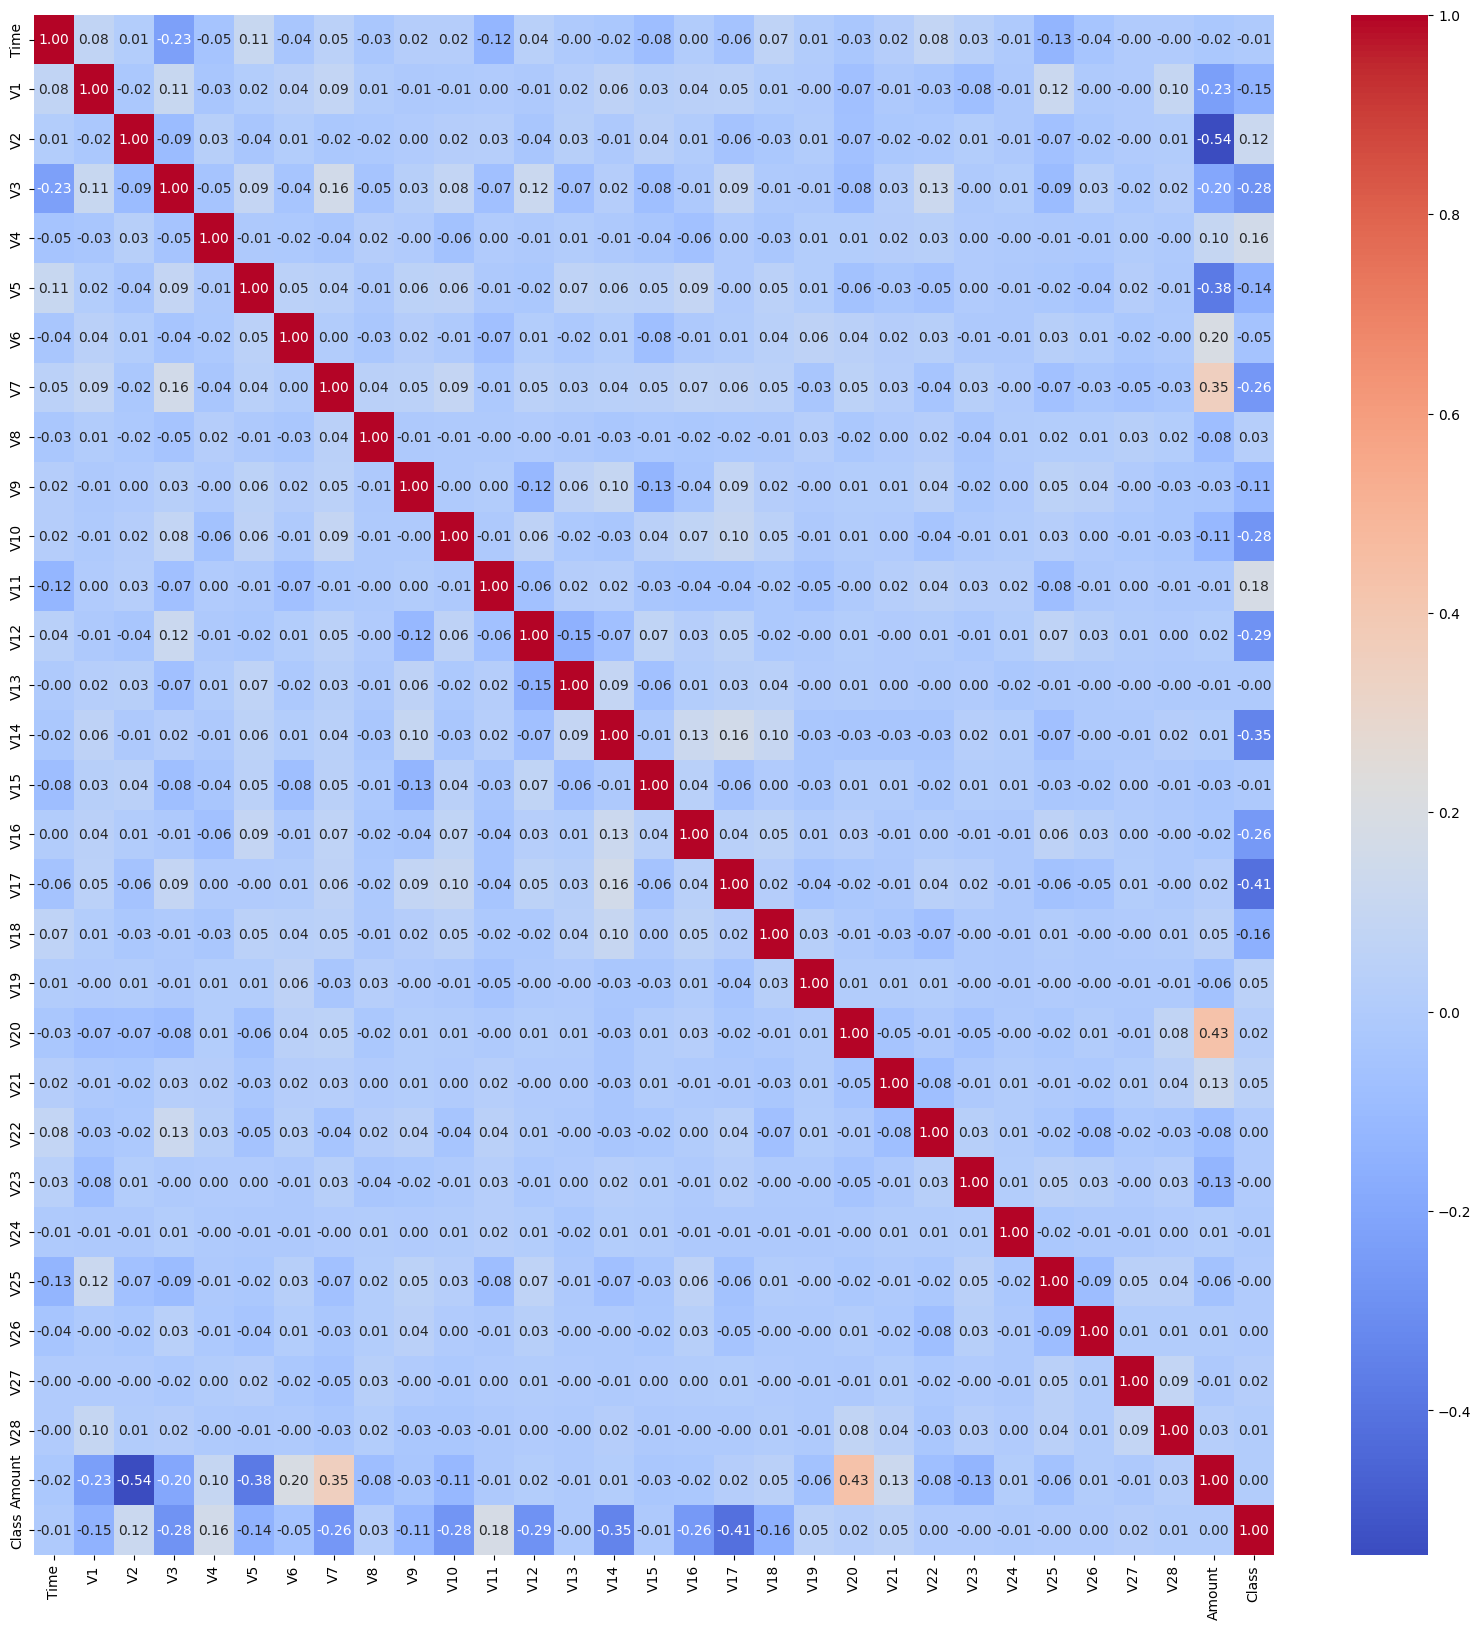

In [7]:
# 상관관계 히트맵 (id column 제외)
corr = train_df.drop(columns=["id"]).corr() 
plt.figure(figsize=(20, 20))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',           
    cmap="coolwarm", 
)
plt.show()

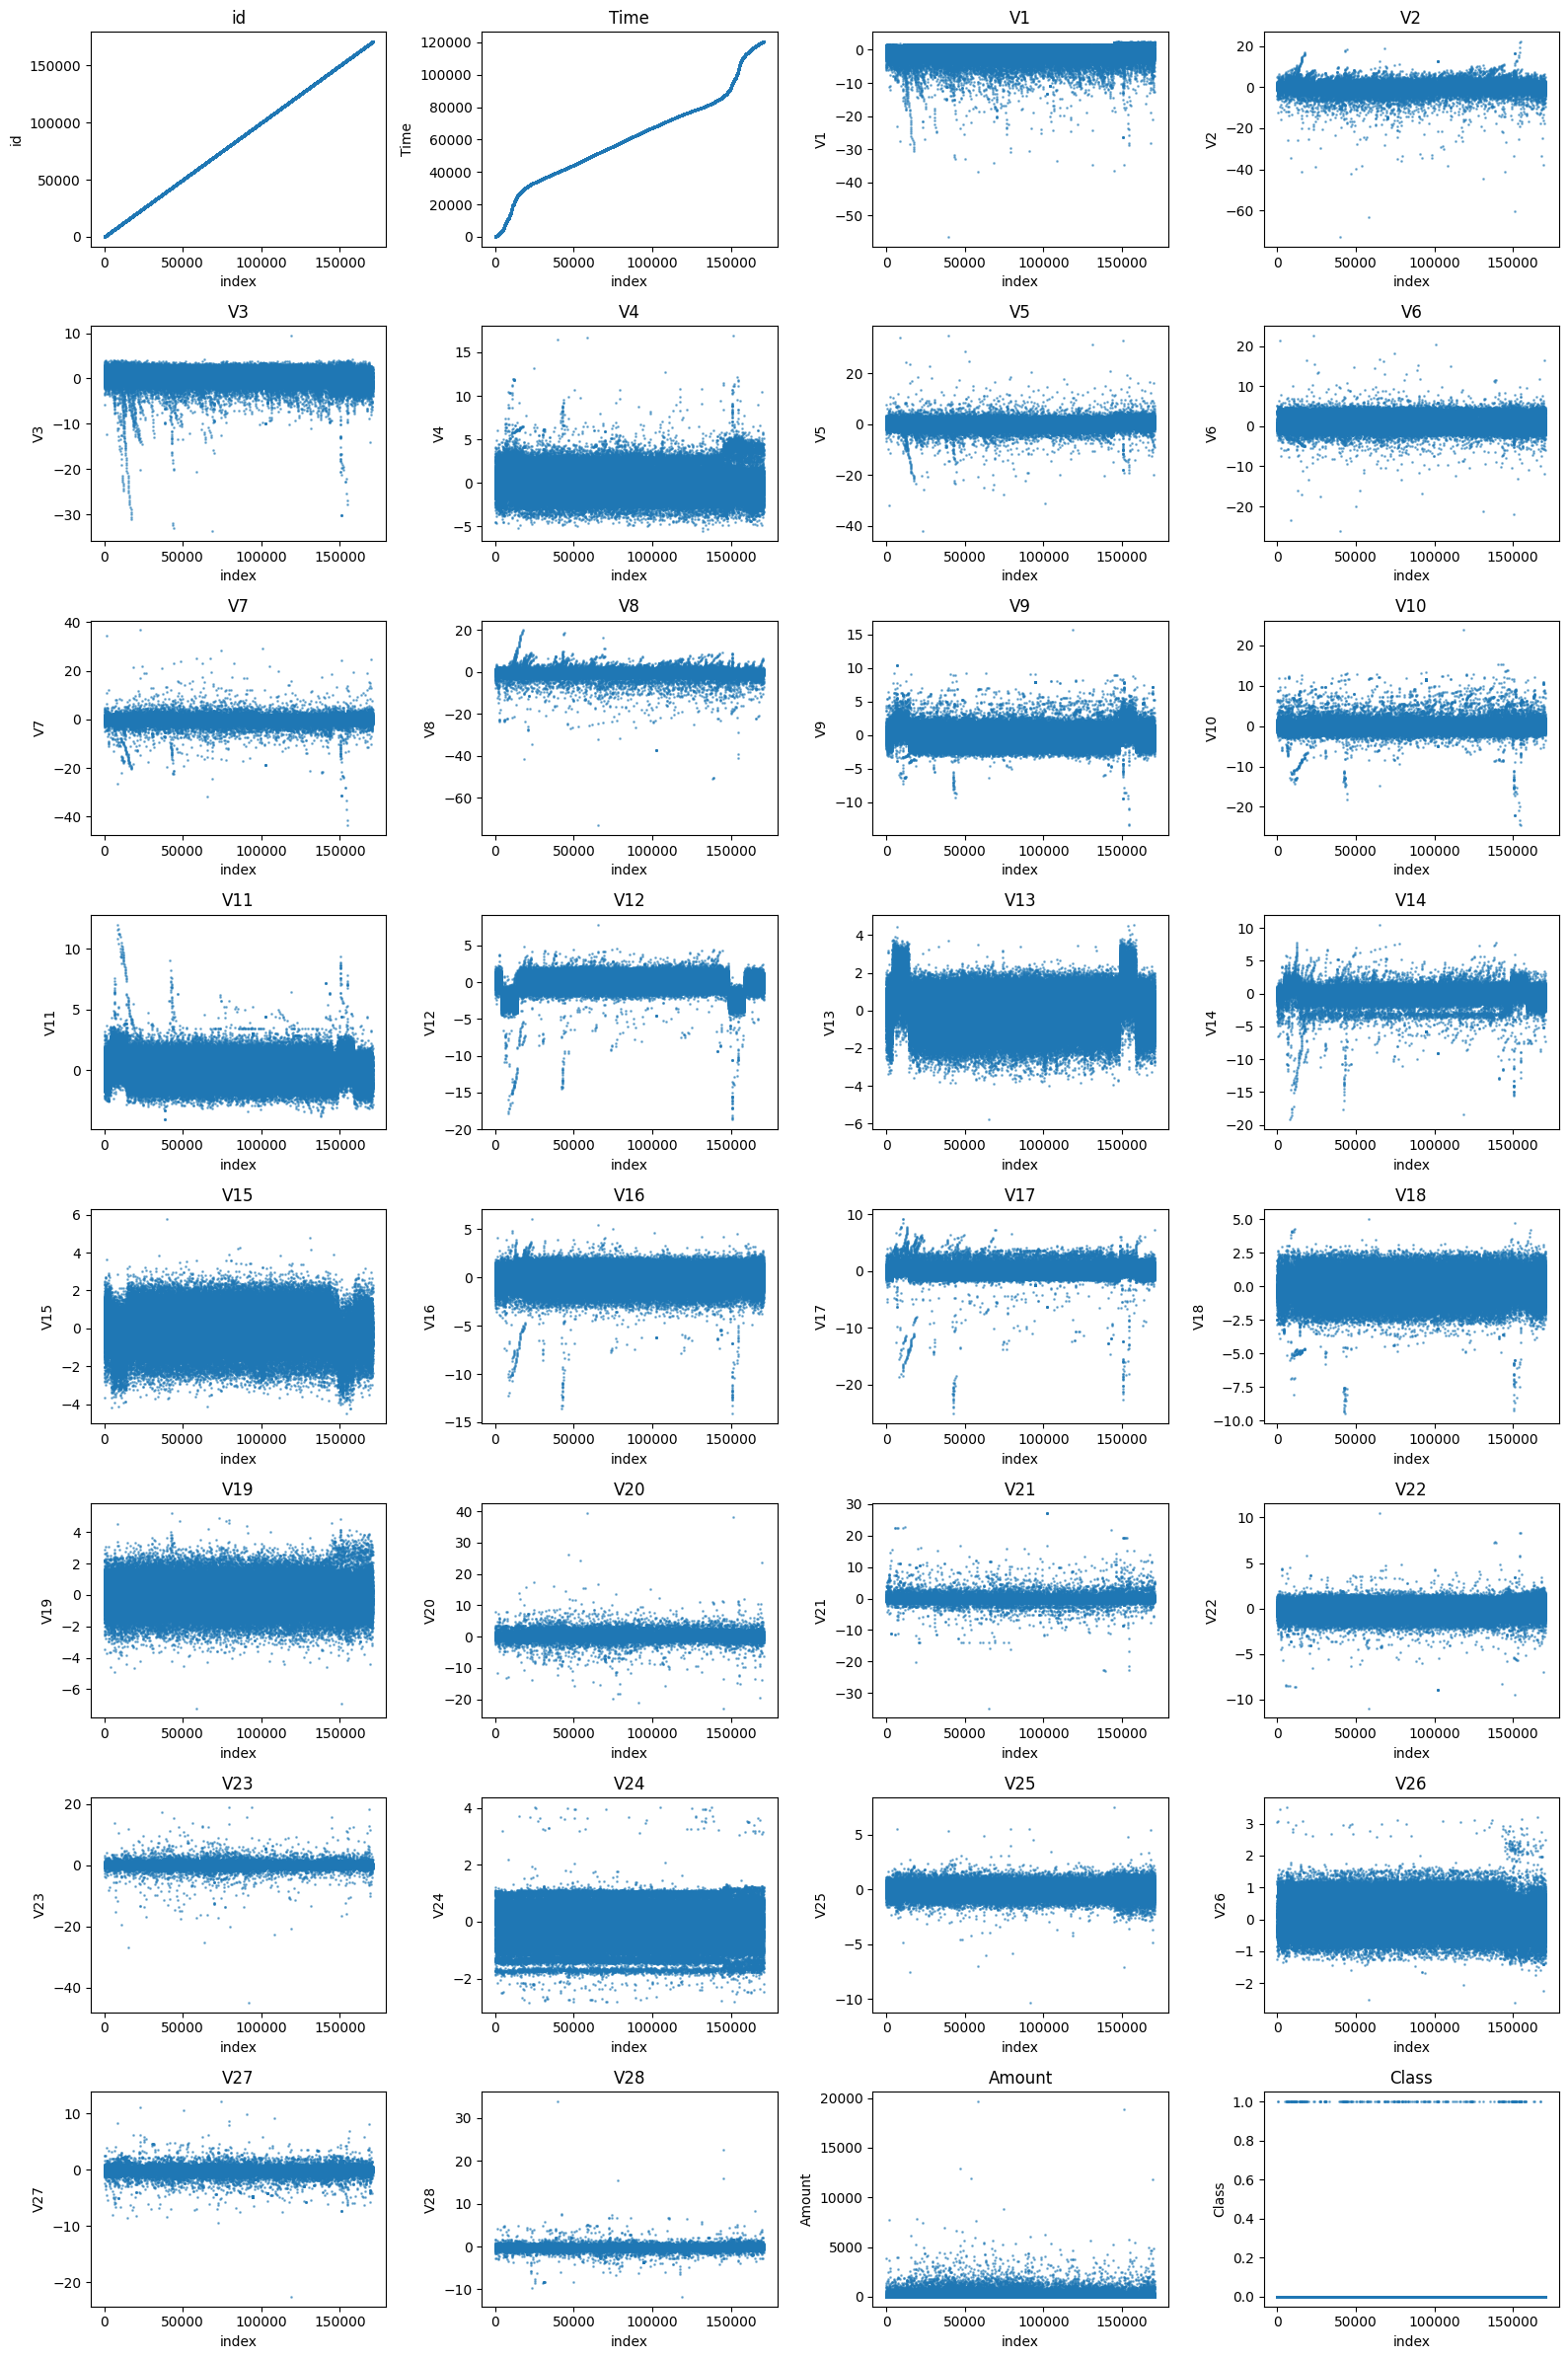

In [8]:
#  컬럼별 index-value scatterplot 작성 

# index 따로 생성
train_with_idx = train_df.copy()
train_with_idx['row_index'] = train_with_idx.index

# 숫자형 컬럼 선택 
num_cols = train_with_idx.select_dtypes(include=['int64', 'float64']).columns
# row_index는 x축으로 쓸 거라 y축 에서 제외
num_cols = [c for c in num_cols if c != 'row_index']

# 한 페이지(Figure)에 여러 서브플롯으로 자료 배치
n_cols = 4
n_rows = int(np.ceil(len(num_cols) / n_cols))

plt.figure(figsize=(4 * n_cols, 3 * n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.scatter(train_with_idx['row_index'], 
                train_with_idx[col],
                s=1, alpha=0.5)
    plt.title(col)
    plt.xlabel('index')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

In [9]:
#  Time 컬럼 제거 (샘플 노트북과 동일)
train_copy = train_df.copy()
train_copy.drop('Time', axis=1, inplace=True)
train_copy

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170878,170878,2.085243,0.153914,-1.937797,0.455977,0.457744,-1.599438,0.828357,-0.606184,0.266940,...,0.146098,0.674611,-0.092485,0.116184,0.578814,-0.074287,-0.049963,-0.071206,13.12,0
170879,170879,1.941601,-0.105717,-2.025099,0.021689,1.257679,1.180161,-0.212451,0.406611,0.369452,...,-0.275532,-0.651069,0.353144,-1.058401,-0.454839,0.282256,-0.022103,-0.058297,1.98,0
170880,170880,-0.184060,1.192288,-0.831053,-0.379134,0.898165,-0.494622,0.780753,-0.873814,-0.297296,...,0.755613,-0.315061,0.223707,0.640872,-1.259095,0.179031,0.105884,0.271658,17.60,0
170881,170881,1.418125,-1.676690,-0.942455,0.734790,-0.915707,0.286333,-0.420231,0.070484,-0.475192,...,-0.078157,-0.408628,0.023694,0.628874,-0.337955,-0.753715,-0.002207,0.020888,327.60,0


# features-target,  train-val 분할

In [10]:
# id, class column 제거 (학습에 사용할 피쳐만)
X_features = train_copy.drop(['id', 'Class'], axis=1)
y_target = train_copy['Class']

In [11]:
# 사이킷런 모듈 활용하여 train-val 데이터 분할
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X_features, y_target, 
                                                  test_size=0.2, # 20% val, 80% train
                                                  random_state=42, 
                                                  stratify=y_target) # 클래스 비율을 유지하면서 분할

In [12]:
# train-val 데이터셋 레이블 비율 확인 
print('학습 데이터 간 레이블 값 비율')
print(y_train.value_counts()/y_train.shape[0] * 100)
print('검증 데이터 간 레이블 값 비율')
print(y_val.value_counts()/y_val.shape[0] * 100)

학습 데이터 간 레이블 값 비율
Class
0    99.789329
1     0.210671
Name: count, dtype: float64
검증 데이터 간 레이블 값 비율
Class
0    99.789332
1     0.210668
Name: count, dtype: float64


# base - line 모델 (로지스틱 회귀)

In [13]:
from sklearn.linear_model import LogisticRegression

# 학습 데이터로 모델 학습
lr_clf = LogisticRegression(max_iter=1000, random_state=42) # max_iter=1000: 최대 반복 횟수
lr_clf.fit(X_train, y_train)

# 검증 데이터로 예측
    # predict(): threshold=0.5 기준
    # predict_proba(): 각 클래스일 확률 예측
lr_val = lr_clf.predict(X_val)
lr_val_proba = lr_clf.predict_proba(X_val)[:,1]


# 모델 평가
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("lr_val_confusion mat:")
print(confusion_matrix (y_val, lr_val))
print("lr_val 정확도: ",accuracy_score(y_val, lr_val))
print("lr_val 정밀도: ",precision_score(y_val, lr_val))
print("lr_val 재현율: ",recall_score(y_val, lr_val))
print("lr_val F1 score: ",f1_score(y_val, lr_val))
print("lr_val AUC: ",roc_auc_score(y_val, lr_val_proba))


lr_val_confusion mat:
[[34093    12]
 [   28    44]]
lr_val 정확도:  0.9988296222605846
lr_val 정밀도:  0.7857142857142857
lr_val 재현율:  0.6111111111111112
lr_val F1 score:  0.6875
lr_val AUC:  0.9746839824724299


# 평가 함수 정의
- Threshold 조정으로 Precision - Recall 개선 가능 -> Threshold 최적화를 위한 함수 필요 

In [14]:
# y_true(실제값), y_pred(예측값), y_proba 입력하여 지표 계산 
"""
모델 평가 함수: 여러 지표를 한번에 계산+출력
Parameters:
- y_true: 실제 레이블 (정답)
- y_pred: 예측 레이블
- y_proba: 예측 확률 
- model_name: 모델 이름 (출력용)
"""

from sklearn.metrics import average_precision_score

def model_eval(y_true, y_pred, y_proba, model_name="Model"):
    # 혼동 행렬 및 기본 지표 계산 및 변수 할당
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    # ROC-AUC, PR-AUC 계산 및 변수 할당
    roc_auc = roc_auc_score(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)
    
    # 결과 출력
    print(f"\n{'='*50}")
    print(f"{model_name} 평가 결과")
    print(f"{'='*50}")
    print(f"confusion mat:\n{cm}")
    print(f"\n정확도 (Accuracy): {acc:.4f}")
    print(f"정밀도 (Precision): {prec:.4f}")
    print(f"재현율 (Recall): {rec:.4f}")
    print(f"F1 score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"PR-AUC: {pr_auc:.4f}")
    print(f"{'='*50}\n")
    
    return {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc
    }

In [15]:
# Baseline 로지스틱 모델 평가
lr_model_eval = model_eval(y_val, lr_val, lr_val_proba, "Baseline Logistic Regression")


Baseline Logistic Regression 평가 결과
confusion mat:
[[34093    12]
 [   28    44]]

정확도 (Accuracy): 0.9988
정밀도 (Precision): 0.7857
재현율 (Recall): 0.6111
F1 score: 0.6875
ROC-AUC: 0.9747
PR-AUC: 0.7628



In [16]:

# y_true(실제값) y_proba 입력하여 thresholds 최적값 찾기 

"""
여러 threshold 비교하여  F1 계산 + 최적 threshold 찾기

Parameters:
- y_true: 실제 레이블
- y_proba: 예측 확률
- thresholds: 테스트할 threshold 리스트 (기본값: 0.1~0.9)

Returns:
- best_threshold: 최고 F1 점수를 내는 threshold
- results_df: 각 threshold별 결과를 담은 DataFrame
"""

def best_thresholds(y_true, y_proba):

    thresholds = np.arange(0.1, 1.0, 0.05)
    
    results = []
    
    for thr in thresholds:
        # 각 threshold로 예측
        y_pred = (y_proba >= thr).astype(int)
        
        # 지표 계산
        prec = precision_score(y_true, y_pred)
        rec = recall_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)
        
        results.append({
            'threshold': thr,
            'precision': prec,
            'recall': rec,
            'f1': f1
        })
    
    # 계산된 지표값으로 DataFrame 작성 
    results_df = pd.DataFrame(results)
    
    # F1 최대값인 threshold 찾기
    best_row = results_df.loc[results_df['f1'].idxmax()] # F1이 최대인 행 추출
    best_threshold = best_row['threshold'] # F1이 최대인 행에서 threshold 추출 
    best_f1 = best_row['f1'] # 최고 f1 점수 변수 저장 
    
    print(f"최적 Threshold: {best_threshold:.4f}")
    print(f"최고 F1: {best_f1:.4f}")
    
    return best_threshold, results_df

In [17]:
# Baseline 모델의 최적 threshold 찾기
best_thr_lr, lr_thr_results = best_thresholds(y_val, lr_val_proba)

최적 Threshold: 0.1000
최고 F1: 0.7692


# 불균형 처리
- lass_weight='balanced': 클래스 비율에 따라 자동으로 가중치 조정
- SMOTE : 소수 클래스 샘플 추가생성

## class_weight='balanced'

In [18]:
# 모델 학습
lr_balanced = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_balanced.fit(X_train, y_train)

# 예측
lr_bal_pred = lr_balanced.predict(X_val)
lr_bal_proba = lr_balanced.predict_proba(X_val)[:, 1]

# 평가
lr_bal_metrics = model_eval(y_val, lr_bal_pred, lr_bal_proba, 
                                 "Logistic Regression (class_weight='balanced')")

# 최적 threshold 찾기
best_thr_lr_bal, lr_bal_thr_results = best_thresholds(y_val, lr_bal_proba)


Logistic Regression (class_weight='balanced') 평가 결과
confusion mat:
[[33364   741]
 [    7    65]]

정확도 (Accuracy): 0.9781
정밀도 (Precision): 0.0806
재현율 (Recall): 0.9028
F1 score: 0.1481
ROC-AUC: 0.9831
PR-AUC: 0.7378

최적 Threshold: 0.9500
최고 F1: 0.6596


## SMOTE

In [19]:

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# 모델 학습
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_smote, y_train_smote)

# 예측 (검증 데이터는 원본 그대로 사용)
lr_smote_pred = lr_smote.predict(X_val)
lr_smote_proba = lr_smote.predict_proba(X_val)[:, 1]

# 평가
lr_smote_metrics = model_eval(y_val, lr_smote_pred, lr_smote_proba, 
                                   "Logistic Regression (SMOTE)")

# 최적 threshold 찾기
best_thr_lr_smote, lr_smote_thr_results = best_thresholds(y_val, lr_smote_proba)


Logistic Regression (SMOTE) 평가 결과
confusion mat:
[[33511   594]
 [    7    65]]

정확도 (Accuracy): 0.9824
정밀도 (Precision): 0.0986
재현율 (Recall): 0.9028
F1 score: 0.1778
ROC-AUC: 0.9809
PR-AUC: 0.7042

최적 Threshold: 0.9500
최고 F1: 0.6049


# 다양한 모델 실험 (+GridSearchCV)
- Random Forest
- XGBoost
- LightGBM

## Random Forest

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV


# 탐색할 파라미터 그리드 설정
param_grid_rf = {
    'n_estimators': [100, 200],   
    'max_depth': [10, 15],            
    'min_samples_split': [30, 50]  
}

# 베이스 모델
rf_base = RandomForestClassifier(
    min_samples_leaf=20,
    class_weight='balanced_subsample',  # 각 트리마다 클래스 가중치 조정
    random_state=42,
    n_jobs=-1  # 모든 CPU 코어 사용
)

# GridSearchCV 설정
grid_search_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    cv=3,  # 3-fold cross-validation
    scoring='f1',  # F1 점수 기준 최적화
    n_jobs=-1,  # 모든 CPU 코어 사용
    verbose=2,  # 진행 상황 표시
    return_train_score=False,  # 속도 향상
    pre_dispatch='2*n_jobs'  # 메모리 관리
)

# 그리드 서치 실행
print(f"\n{'='*60}")
print(f"Random Forest GridSearchCV 시작")
grid_search_rf.fit(X_train, y_train)
print(f"\n{'='*60}")

# 최적 파라미터 및 결과 출력
print(f"\n{'='*60}")
print(f"최적 파라미터: {grid_search_rf.best_params_}")
print(f"최고 CV F1 Score: {grid_search_rf.best_score_:.4f}")
print(f"{'='*60}\n")

# 최적 모델로 예측
rf_clf = grid_search_rf.best_estimator_
rf_pred = rf_clf.predict(X_val)
rf_proba = rf_clf.predict_proba(X_val)[:, 1]

# 평가
rf_metrics = model_eval(y_val, rf_pred, rf_proba, "Random Forest (GridSearchCV)")

# 최적 threshold 찾기
best_thr_rf, rf_thr_results = best_thresholds(y_val, rf_proba)


Random Forest GridSearchCV 시작
Fitting 3 folds for each of 8 candidates, totalling 24 fits


최적 파라미터: {'max_depth': 15, 'min_samples_split': 50, 'n_estimators': 100}
최고 CV F1 Score: 0.8342


Random Forest (GridSearchCV) 평가 결과
confusion mat:
[[34090    15]
 [    9    63]]

정확도 (Accuracy): 0.9993
정밀도 (Precision): 0.8077
재현율 (Recall): 0.8750
F1 score: 0.8400
ROC-AUC: 0.9791
PR-AUC: 0.7922

최적 Threshold: 0.7500
최고 F1: 0.8493


## XGBoost

In [21]:
from xgboost import XGBClassifier

# scale_pos_weight: P 클래스에 대한 가중치 (불균형 처리)
# 계산: (F 클래스 수) / ( P 클래스 수)
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

# 탐색할 파라미터 그리드 정의
param_grid_xgb = {
    'n_estimators': [100, 200],        
    'max_depth': [3, 5, 7],            
    'learning_rate': [0.05, 0.1]       
}

# 베이스 모델
xgb_base = XGBClassifier(
    subsample=0.8,         
    colsample_bytree=0.8,  
    scale_pos_weight=scale_pos_weight,  # 클래스 불균형 처리
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# GridSearchCV 설정
grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=2,
    return_train_score=False,
    pre_dispatch='2*n_jobs'
)

# 그리드 서치 실행
print(f"\n{'='*60}")
print(f"XGBoost GridSearchCV 시작")
grid_search_xgb.fit(X_train, y_train)
print(f"{'='*60}\n")


# 최적 파라미터 및 결과 출력
print(f"\n{'='*60}")
print(f"GridSearchCV 완료!")
print(f"최적 파라미터: {grid_search_xgb.best_params_}")
print(f"최고 CV F1 Score: {grid_search_xgb.best_score_:.4f}")
print(f"{'='*60}\n")

# 최적 모델로 예측
xgb_clf = grid_search_xgb.best_estimator_
xgb_pred = xgb_clf.predict(X_val)
xgb_proba = xgb_clf.predict_proba(X_val)[:, 1]

# 평가
xgb_metrics = model_eval(y_val, xgb_pred, xgb_proba, "XGBoost (GridSearchCV)")

# 최적 threshold 찾기
best_thr_xgb, xgb_thr_results = best_thresholds(y_val, xgb_proba)


XGBoost GridSearchCV 시작
Fitting 3 folds for each of 12 candidates, totalling 36 fits


GridSearchCV 완료!
최적 파라미터: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
최고 CV F1 Score: 0.8670


XGBoost (GridSearchCV) 평가 결과
confusion mat:
[[34101     4]
 [    9    63]]

정확도 (Accuracy): 0.9996
정밀도 (Precision): 0.9403
재현율 (Recall): 0.8750
F1 score: 0.9065
ROC-AUC: 0.9745
PR-AUC: 0.8831

최적 Threshold: 0.8000
최고 F1: 0.9265


## LightGBM

In [22]:
from lightgbm import LGBMClassifier

# 탐색할 파라미터 그리드 정의
param_grid_lgbm = {
    'n_estimators': [100, 200],        
    'max_depth': [5, 7],               
    'num_leaves': [31, 50]        
}

# 베이스 모델 
lgbm_base = LGBMClassifier(
    learning_rate=0.1,
    min_child_samples=20,  
    subsample=0.8,
    colsample_bytree=0.8,
    is_unbalance=True,     # 클래스 불균형 자동 처리
    objective='binary',
    random_state=42,
    n_jobs=-1,
    verbose=-1  # 경고 메시지 숨기기
)

# GridSearchCV 설정
grid_search_lgbm = GridSearchCV(
    estimator=lgbm_base,
    param_grid=param_grid_lgbm,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=2,
    return_train_score=False,
    pre_dispatch='2*n_jobs'
)

# 그리드 서치 실행
print(f"\n{'='*60}")
print(f"LightGBM GridSearchCV 시작")
print(f"{'='*60}\n")

grid_search_lgbm.fit(X_train, y_train)

# 최적 파라미터 및 결과 출력
print(f"\n{'='*60}")
print(f"GridSearchCV 완료!")
print(f"최적 파라미터: {grid_search_lgbm.best_params_}")
print(f"최고 CV F1 Score: {grid_search_lgbm.best_score_:.4f}")
print(f"{'='*60}\n")

# 최적 모델로 예측
lgbm_clf = grid_search_lgbm.best_estimator_
lgbm_pred = lgbm_clf.predict(X_val)
lgbm_proba = lgbm_clf.predict_proba(X_val)[:, 1]

# 평가
lgbm_metrics = model_eval(y_val, lgbm_pred, lgbm_proba, "LightGBM (GridSearchCV)")

# 최적 threshold 찾기
best_thr_lgbm, lgbm_thr_results = best_thresholds(y_val, lgbm_proba)


LightGBM GridSearchCV 시작

Fitting 3 folds for each of 8 candidates, totalling 24 fits

GridSearchCV 완료!
최적 파라미터: {'max_depth': 7, 'n_estimators': 100, 'num_leaves': 50}
최고 CV F1 Score: 0.1425


LightGBM (GridSearchCV) 평가 결과
confusion mat:
[[32316  1789]
 [    8    64]]

정확도 (Accuracy): 0.9474
정밀도 (Precision): 0.0345
재현율 (Recall): 0.8889
F1 score: 0.0665
ROC-AUC: 0.9206
PR-AUC: 0.0325

최적 Threshold: 0.9500
최고 F1: 0.0673


# 앙상블 (Soft Voting)
- 여러 모델의 예측 확률을 평균내어 최종 예측 수행

In [23]:
# 모든 모델의 결과를 비교 테이블로 정리


comparison_results = []

# 각 모델별 최적 threshold에서 성능 기록
models_info = [
    ("Baseline LR", lr_val_proba, best_thr_lr),
    ("LR (balanced)", lr_bal_proba, best_thr_lr_bal),
    ("LR (SMOTE)", lr_smote_proba, best_thr_lr_smote),
    ("Random Forest + grid", rf_proba, best_thr_rf),
    ("XGBoost + grid", xgb_proba, best_thr_xgb),
    ("LightGBM + grid", lgbm_proba, best_thr_lgbm)
]

for model_name, proba, best_thr in models_info:
    # 최적 threshold로 예측
    pred = (proba >= best_thr).astype(int)
    
    # 지표 계산
    f1 = f1_score(y_val, pred)
    prec = precision_score(y_val, pred, zero_division=0)
    rec = recall_score(y_val, pred, zero_division=0)
    roc_auc = roc_auc_score(y_val, proba)
    pr_auc = average_precision_score(y_val, proba)
    
    # 딕셔너리 생성
    comparison_results.append({
        'Model': model_name,
        'Best Threshold': best_thr,
        'F1 Score': f1,
        'Precision': prec,
        'Recall': rec,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc
    })

# 딕셔너리 -> DateFrame으로 변환
comparison_df = pd.DataFrame(comparison_results)

# F1 점수 기준으로 정렬
comparison_df = comparison_df.sort_values('F1 Score', ascending=False)

print("\n" + "="*80)
print("모델 성능 비교표 (F1 Score 기준 정렬)")
print(comparison_df.to_string(index=False))
print("="*80)


모델 성능 비교표 (F1 Score 기준 정렬)
               Model  Best Threshold  F1 Score  Precision   Recall  ROC-AUC   PR-AUC
      XGBoost + grid            0.80  0.926471   0.984375 0.875000 0.974459 0.883054
Random Forest + grid            0.75  0.849315   0.837838 0.861111 0.979069 0.792184
         Baseline LR            0.10  0.769231   0.774648 0.763889 0.974684 0.762824
       LR (balanced)            0.95  0.659574   0.534483 0.861111 0.983122 0.737836
          LR (SMOTE)            0.95  0.604878   0.466165 0.861111 0.980935 0.704180
     LightGBM + grid            0.95  0.067298   0.034973 0.888889 0.920642 0.032478


In [24]:
# 상위 3개 모델을 앙상블 (XGB, RF, LGBM)
print("\n[6] 앙상블 모델 (XGB + RF + LGBM)")
print("-" * 50)

# 세 모델의 예측 확률 평균
ensemble_proba = (xgb_proba + rf_proba + lgbm_proba) / 3

# 기본 threshold(0.5)로 예측
ensemble_pred = (ensemble_proba >= 0.5).astype(int)

# 평가
ensemble_metrics = model_eval(y_val, ensemble_pred, ensemble_proba, "Ensemble (RF+XGB+LGBM)")

# 최적 threshold 찾기
best_thr_ensemble, ensemble_thr_results = best_thresholds(y_val, ensemble_proba)


[6] 앙상블 모델 (XGB + RF + LGBM)
--------------------------------------------------

Ensemble (RF+XGB+LGBM) 평가 결과
confusion mat:
[[34086    19]
 [    9    63]]

정확도 (Accuracy): 0.9992
정밀도 (Precision): 0.7683
재현율 (Recall): 0.8750
F1 score: 0.8182
ROC-AUC: 0.9790
PR-AUC: 0.8781

최적 Threshold: 0.8500
최고 F1: 0.9185


# 모델 성능 비교

In [25]:
# 앙상블 결과를 비교 테이블에 추가
ensemble_pred_opt = (ensemble_proba >= best_thr_ensemble).astype(int)

comparison_results.append({
    'Model': 'Ensemble (RF+XGB+LGBM)',
    'Best Threshold': best_thr_ensemble,
    'F1 Score': f1_score(y_val, ensemble_pred_opt),
    'Precision': precision_score(y_val, ensemble_pred_opt, zero_division=0),
    'Recall': recall_score(y_val, ensemble_pred_opt, zero_division=0),
    'ROC-AUC': roc_auc_score(y_val, ensemble_proba),
    'PR-AUC': average_precision_score(y_val, ensemble_proba)
})

# 최종 비교 테이블
final_comparison_df = pd.DataFrame(comparison_results)
final_comparison_df = final_comparison_df.sort_values('F1 Score', ascending=False)

print("\n" + "="*80)
print("최종 모델 성능 비교표 (앙상블 포함)")
print(final_comparison_df.to_string(index=False))
print("="*80)


최종 모델 성능 비교표 (앙상블 포함)
                 Model  Best Threshold  F1 Score  Precision   Recall  ROC-AUC   PR-AUC
        XGBoost + grid            0.80  0.926471   0.984375 0.875000 0.974459 0.883054
Ensemble (RF+XGB+LGBM)            0.85  0.918519   0.984127 0.861111 0.979034 0.878071
  Random Forest + grid            0.75  0.849315   0.837838 0.861111 0.979069 0.792184
           Baseline LR            0.10  0.769231   0.774648 0.763889 0.974684 0.762824
         LR (balanced)            0.95  0.659574   0.534483 0.861111 0.983122 0.737836
            LR (SMOTE)            0.95  0.604878   0.466165 0.861111 0.980935 0.704180
       LightGBM + grid            0.95  0.067298   0.034973 0.888889 0.920642 0.032478


In [26]:
# 최고 F1 점수를 낸 모델 확인
best_model_name = final_comparison_df.iloc[0]['Model']
best_model_f1 = final_comparison_df.iloc[0]['F1 Score']

print(f"\n최고 성능 모델: {best_model_name}")
print(f"F1 Score: {best_model_f1:.4f}")
print("\n이 모델을 사용하여 최종 제출 파일을 생성합니다.")


최고 성능 모델: XGBoost + grid
F1 Score: 0.9265

이 모델을 사용하여 최종 제출 파일을 생성합니다.


# 최종 모델 선택 및 제출 파일 생성

In [27]:
# scale_pos_weight 다시 계산
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

# 전체 데이터 준비
X_full = pd.concat([X_train, X_val], axis=0)
y_full = pd.concat([y_train, y_val], axis=0)

# 모델 재학습 (최적 파라미터 사용)
xgb_final = XGBClassifier(
    **grid_search_xgb.best_params_,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
xgb_final.fit(X_full, y_full)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, gpu_id=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, predictor=None, random_state=42, ...)

In [28]:
# 테스트 데이터 전처리 (학습 데이터와 동일하게)
test_copy = test_df.copy()

# Time 컬럼 제거 (이미 제거되었는지 확인)
if 'Time' in test_copy.columns:
    test_copy.drop('Time', axis=1, inplace=True)

# id 컬럼 분리
test_ids = test_copy['id']
X_test = test_copy.drop('id', axis=1)

# XGB 모델 예측
xgb_test_proba = xgb_final.predict_proba(X_test)[:, 1]

# 최적 threshold 적용
test_pred = (xgb_test_proba >= best_thr_xgb).astype(int)

print(f"사기 거래 예측 수: {test_pred.sum()}")
print(f"정상 거래 예측 수: {(test_pred == 0).sum()}")

# 제출 파일 생성
submission = pd.DataFrame({
    "id": test_ids,
    "Class": test_pred
})

# CSV 파일 저장
submission.to_csv("./submission.csv", index=False)

print(f"shape: {submission.shape}")

print(submission.head(10))

사기 거래 예측 수: 109
정상 거래 예측 수: 113814
shape: (113923, 2)
       id  Class
0  170883      0
1  170884      0
2  170885      0
3  170886      0
4  170887      0
5  170888      0
6  170889      0
7  170890      0
8  170891      0
9  170892      0
